# Clustering y Regionalización

En esta clase respondemos una pregunta común en el análisis geográfico: dadas muchas variables sobre cada unidad territorial (un censo, una comuna, un barrio), **¿cómo agrupamos las unidades en grupos coherentes?**

Hay dos formas de hacerlo, y la diferencia es central:

- **Clustering** agrupa observaciones que se *parecen entre sí* en sus atributos. No le importa la geografía. Dos polígonos pueden quedar en el mismo grupo aunque estén en extremos opuestos del mapa.
- **Regionalización** agrupa observaciones que se parecen *y* además están **conectadas en el espacio**. Los grupos resultantes son **regiones contiguas**.

El clustering sirve para clasificación (ej. tipologías de barrios). La regionalización sirve para construir unidades operativas (distritos electorales, cuencas, áreas de gestión).

Trabajaremos con datos socioeconómicos de los **census tracts de San Diego** (628 unidades), un caso clásico que permite ver con claridad las diferencias entre los métodos.

## Lo que veremos

1. Exploración de las variables (mapas y autocorrelación espacial).
2. Estandarización: por qué es imprescindible antes de agrupar.
3. Clustering no espacial: **K-Means** y **Clustering Aglomerativo Jerárquico (AHC)**.
4. Por qué los clusters resultan geográficamente fragmentados.
5. Regionalización: AHC con **restricción de contigüidad** (Queen y KNN).
6. Cómo comparar la calidad de los resultados.

Adaptado de Rey, Arribas-Bel & Wolf (2020), *Geographic Data Science with Python*, Capítulo 10.

## 1. Preparación: librerías y datos

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import robust_scale
from sklearn.cluster import KMeans, AgglomerativeClustering
from libpysal.weights import Queen, KNN
from esda.moran import Moran

%config InlineBackend.figure_format = "retina"
np.random.seed(42)

# Configuración de visualización 
sns.set(style='ticks', font='sans-serif', context='notebook', palette='viridis')
plt.rcParams["figure.dpi"] = 96
plt.rcParams["font.family"] = "Fira Sans Extra Condensed"  

pd.set_option('display.max_columns', None)

In [2]:
db = gpd.read_file("datos/external/sandiego/sandiego_tracts.gpkg")
db.shape

(628, 25)

In [3]:
db.head()

,GEOID,median_age,total_pop,total_pop_white,tt_work,hh_total,hh_female,total_bachelor,median_hh_income,income_gini,total_housing_units,total_rented,median_no_rooms,median_house_value,NAME,state,county,tract,area_sqm,pct_rented,pct_hh_female,pct_bachelor,pct_white,sub_30,geometry
0,06073018300,37.1,2590.0,2375.0,1299.0,2590.0,137.0,0.0,62500.0,0.5355,2530.0,946.0,3.9,732900.000000,"Census Tract 183, San Diego County, California",06,073,018300,2.876449,0.373913,0.052896,0.000000,0.916988,False,"POLYGON ((-13069450.120 3922380.770, -13069175..."
1,06073018601,41.2,5147.0,4069.0,1970.0,5147.0,562.0,24.0,88165.0,0.4265,1633.0,335.0,6.5,473800.000000,"Census Tract 186.01, San Diego County, California",06,073,018601,4.548797,0.205144,0.109190,0.004663,0.790558,False,"POLYGON ((-13067719.770 3922939.420, -13067631..."
2,06073017601,54.4,5595.0,4925.0,1702.0,5595.0,442.0,34.0,110804.0,0.4985,2308.0,644.0,6.2,930600.000000,"Census Tract 176.01, San Diego County, California",06,073,017601,8.726275,0.279029,0.078999,0.006077,0.880250,False,"POLYGON ((-13058166.110 3907247.690, -13058140..."
3,06073019301,42.3,7026.0,5625.0,3390.0,7026.0,638.0,46.0,100539.0,0.4003,2351.0,462.0,6.6,478500.000000,"Census Tract 193.01, San Diego County, California",06,073,019301,3.519743,0.196512,0.090806,0.006547,0.800598,False,"POLYGON ((-13056896.290 3925255.610, -13056868..."
4,06073018700,21.8,40402.0,30455.0,24143.0,40402.0,2456.0,23.0,41709.0,0.3196,7523.0,7146.0,5.4,515570.896382,"Census Tract 187, San Diego County, California",06,073,018700,559.150793,0.949887,0.060789,0.000569,0.753799,False,"POLYGON ((-13090788.510 3946435.430, -13090736..."


Cada fila es un *census tract* (unidad censal) de San Diego, con polígono y varias variables socioeconómicas. Vamos a usar nueve de ellas:

In [4]:
cluster_variables = [
    "median_house_value",  # valor mediano de la vivienda
    "pct_white",           # % de población blanca
    "pct_rented",          # % de viviendas arrendadas
    "pct_hh_female",       # % de hogares con jefatura femenina
    "pct_bachelor",        # % de población con título universitario
    "median_no_rooms",     # nº mediano de habitaciones por vivienda
    "income_gini",         # Gini del ingreso dentro del tract
    "median_age",          # edad mediana
    "tt_work",             # tiempo medio de viaje al trabajo
]
len(cluster_variables)

9

## 2. Exploración: ¿hay estructura espacial en las variables?

Antes de agrupar conviene mirar cada variable en el mapa. Si las variables están distribuidas espacialmente al azar, no tendría sentido buscar regiones. Si tienen estructura espacial, sí.

Hagamos un mapa coroplético de cada variable usando cuantiles (esto ya lo vimos en clase 03):

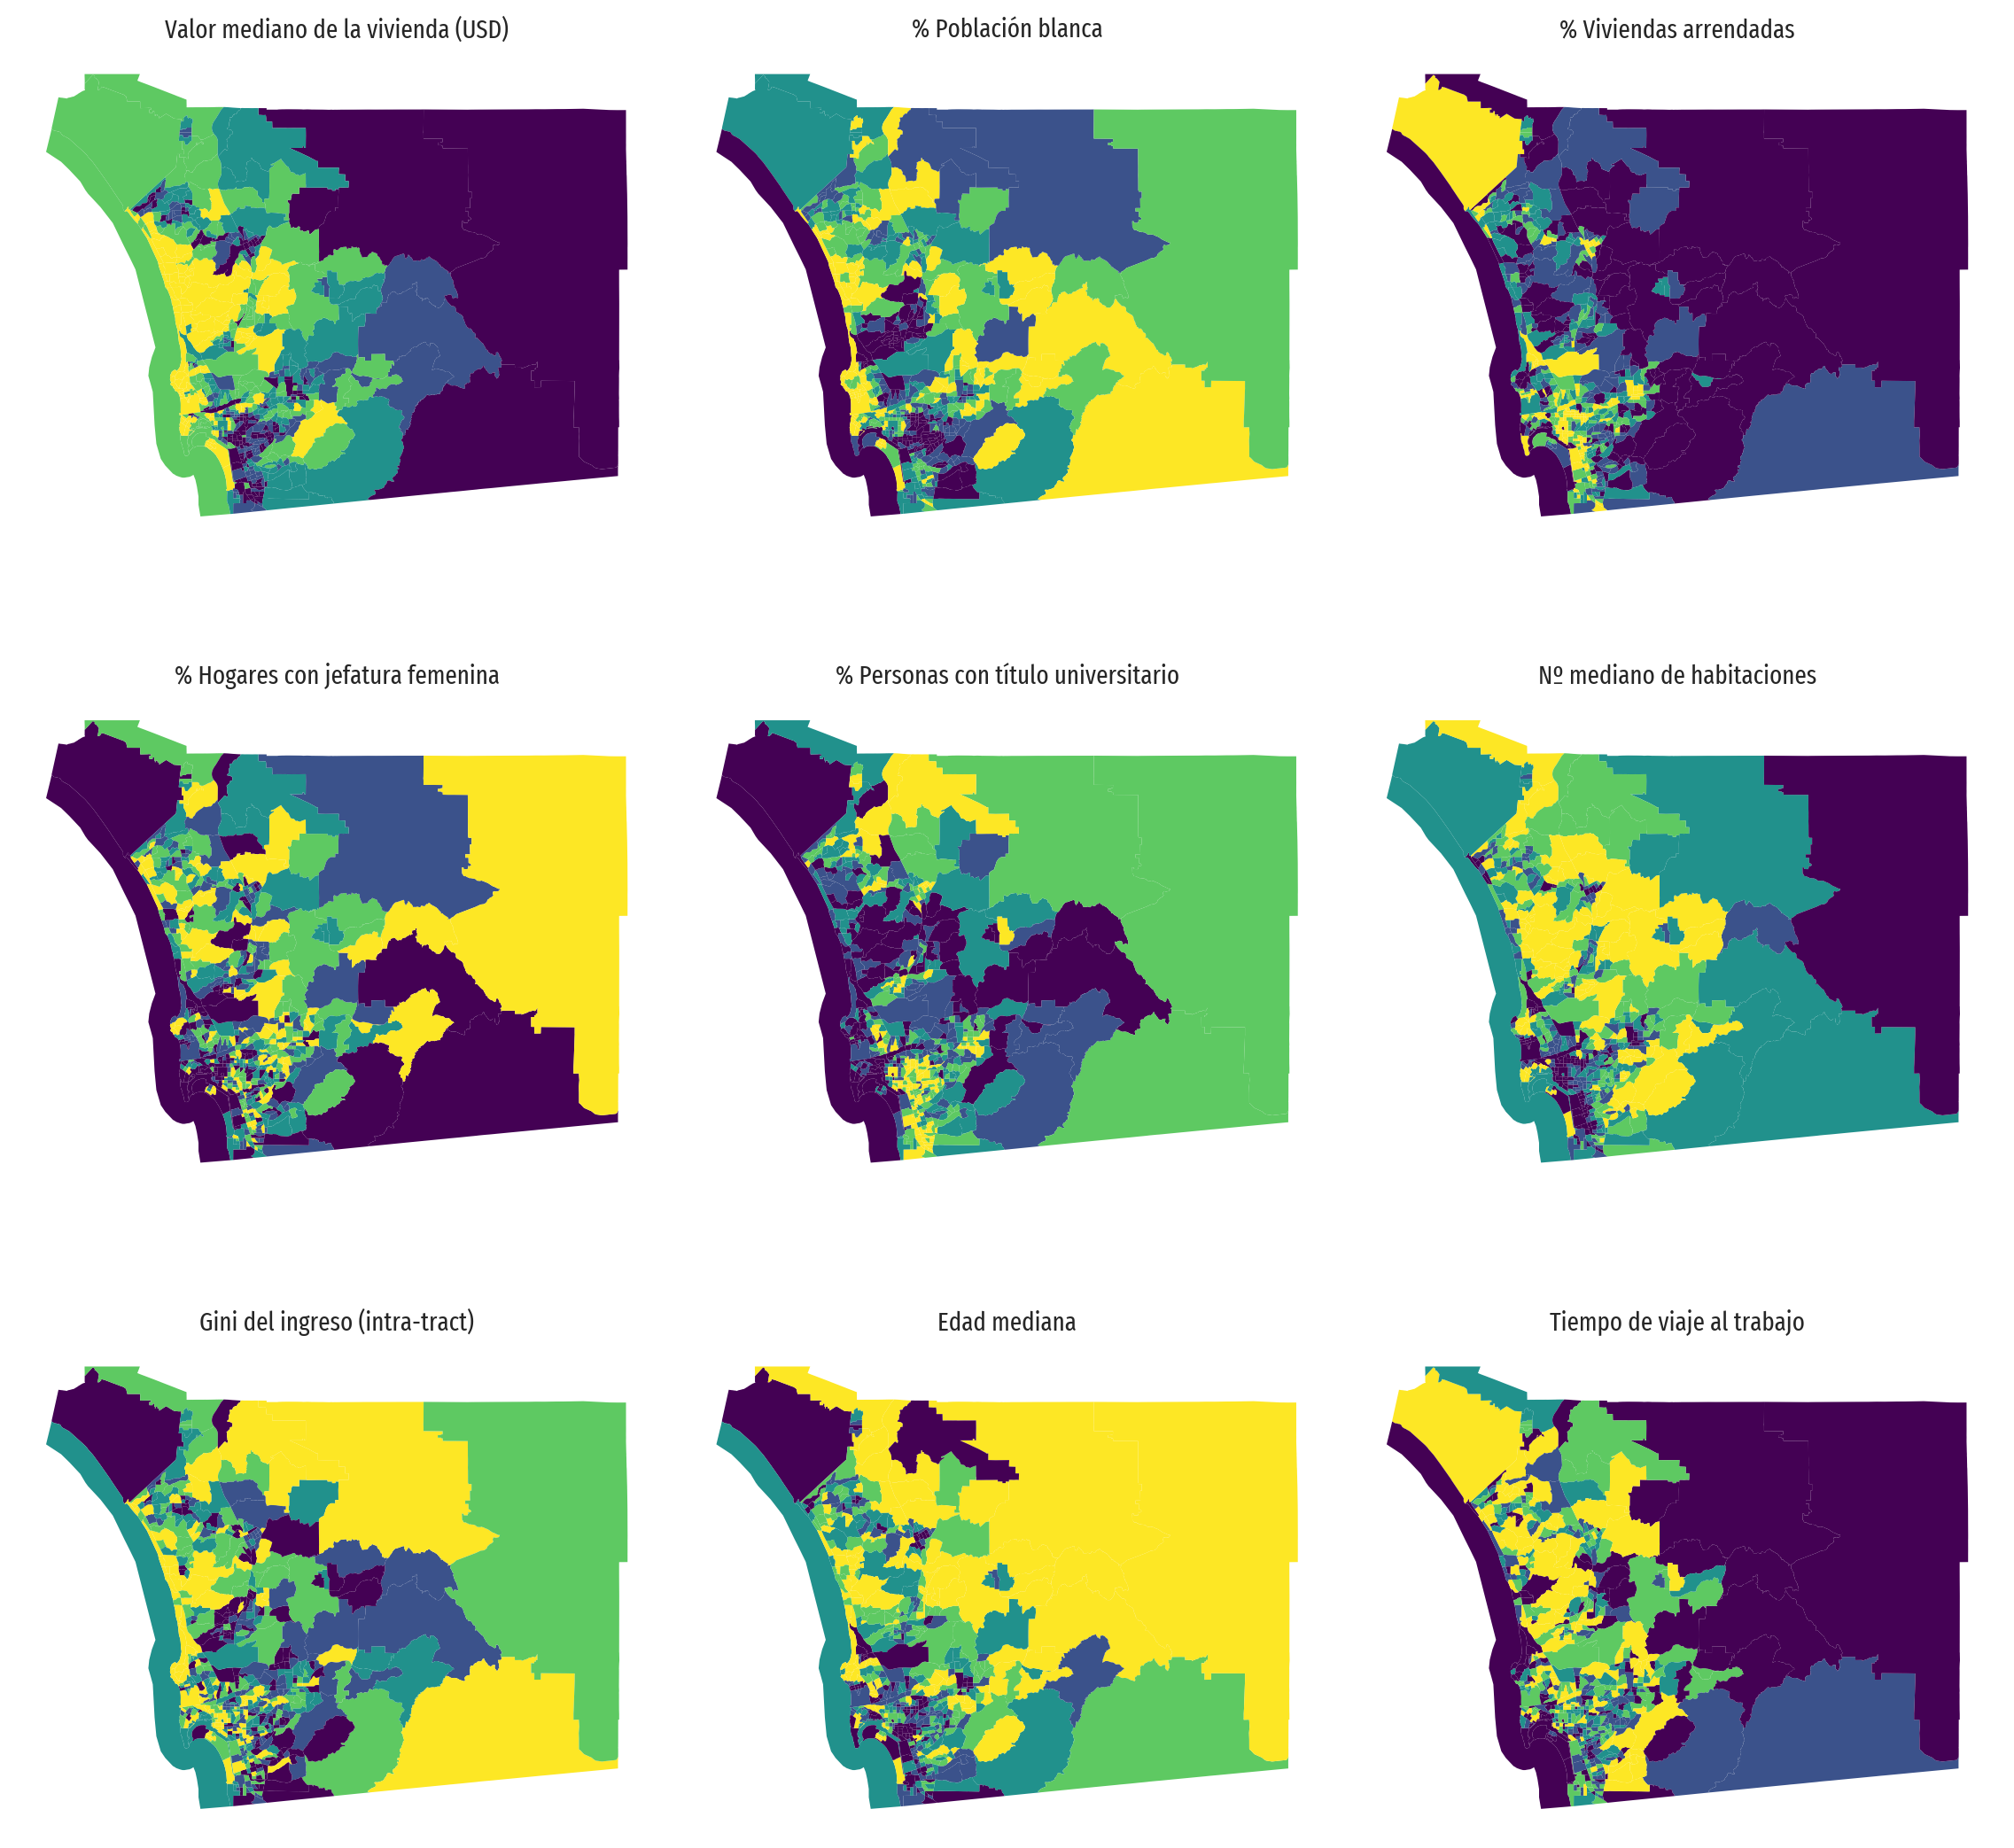

In [5]:
titulos = {
    "median_house_value": "Valor mediano de la vivienda (USD)",
    "pct_white":          "% Población blanca",
    "pct_rented":         "% Viviendas arrendadas",
    "pct_hh_female":      "% Hogares con jefatura femenina",
    "pct_bachelor":       "% Personas con título universitario",
    "median_no_rooms":    "Nº mediano de habitaciones",
    "income_gini":        "Gini del ingreso (intra-tract)",
    "median_age":         "Edad mediana",
    "tt_work":            "Tiempo de viaje al trabajo",
}

fig, axs = plt.subplots(3, 3, figsize=(12, 12))
for ax, var in zip(axs.flatten(), cluster_variables):
    db.plot(
        column=var, scheme="Quantiles", k=5,
        cmap="viridis", linewidth=0, ax=ax,
    )
    ax.set_axis_off()
    ax.set_title(titulos[var], fontsize=11)
plt.tight_layout()
plt.savefig("img/clase07/mapas_9_variables.png", dpi=150, bbox_inches="tight")
plt.show()
plt.show()

A simple vista varias variables muestran patrones geográficos claros (la costa concentra mayores valores de vivienda, ciertas zonas concentran arrendatarios, etc.). Cuantifiquémoslo con **Moran's I** (clase 04):

In [6]:
w = Queen.from_dataframe(db, use_index=False)
w.transform = "r"

moran_I = []
moran_p = []

for v in cluster_variables:
    mo = Moran(db[v], w)
    moran_I.append(mo.I)
    moran_p.append(mo.p_sim)

moran_resumen = pd.DataFrame(
    {"Moran I": moran_I, "p-valor": moran_p},
    index=cluster_variables,
)
moran_resumen

,Moran I,p-valor
median_house_value,0.646618,0.001
pct_white,0.602079,0.001
pct_rented,0.451372,0.001
pct_hh_female,0.282239,0.001
pct_bachelor,0.433082,0.001
median_no_rooms,0.538996,0.001
income_gini,0.295064,0.001
median_age,0.381440,0.001
tt_work,0.102748,0.002


Todas las variables tienen Moran's I positivo y significativo: **hay autocorrelación espacial**. Eso justifica el ejercicio de regionalización: existe estructura geográfica que tiene sentido aprovechar.

## 3. Estandarización

Los métodos de clustering usan **distancias** entre observaciones. Si una variable se mide en miles (`median_house_value` en dólares) y otra entre 0 y 1 (`income_gini`), la primera dominará la distancia y la segunda casi no influirá. Por eso siempre se estandarizan las variables antes de agrupar.

Usamos `robust_scale`, que reemplaza media/desviación por **mediana / rango intercuartil**. Es menos sensible a outliers que el z-score clásico:

$$ x_i^{\text{esc}} = \frac{x_i - \text{mediana}(x)}{Q_{75}(x) - Q_{25}(x)} $$

Tras escalar, todas las variables quedan en una escala comparable, centradas en 0.

In [7]:
db_scaled = robust_scale(db[cluster_variables])
db_scaled[:3]

array([[ 1.16897565,  0.88747229, -0.07925532, -1.85025225, -0.50838531,
        -0.7310384 ,  1.93719258,  0.1011236 , -0.6982584 ],
       [ 0.08123426,  0.20084202, -0.54215204,  0.12495856, -0.23062749,
         0.79837337,  0.28755202,  0.56179775, -0.15471851],
       [ 1.99895046,  0.68795166, -0.33950017, -0.9343542 , -0.14640241,
         0.62190278,  1.37722285,  2.04494382, -0.37181045]])

## 4. K-Means

K-Means es el algoritmo de clustering más usado. La idea es muy simple:

1. Elegimos un número $k$ de grupos.
2. Inicializamos $k$ centroides al azar en el espacio de variables.
3. Asignamos cada observación al centroide más cercano.
4. Recalculamos los centroides como el **promedio** de las observaciones asignadas.
5. Repetimos 3 y 4 hasta que las asignaciones no cambian.

El criterio que minimiza es la **suma de distancias al cuadrado dentro de cada cluster** (within-cluster sum of squares):

$$ \text{WCSS} = \sum_{c=1}^{k} \sum_{i \in C_c} \| x_i - \mu_c \|^2 $$

donde $\mu_c$ es el centroide del cluster $c$.

Apliquémoslo con $k=5$:

In [8]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(db_scaled)
db["k5"] = kmeans.labels_
db["k5"].value_counts().sort_index()

k5
0    245
1    246
2     40
3     88
4      9
Name: count, dtype: int64

Veamos los grupos en el mapa:

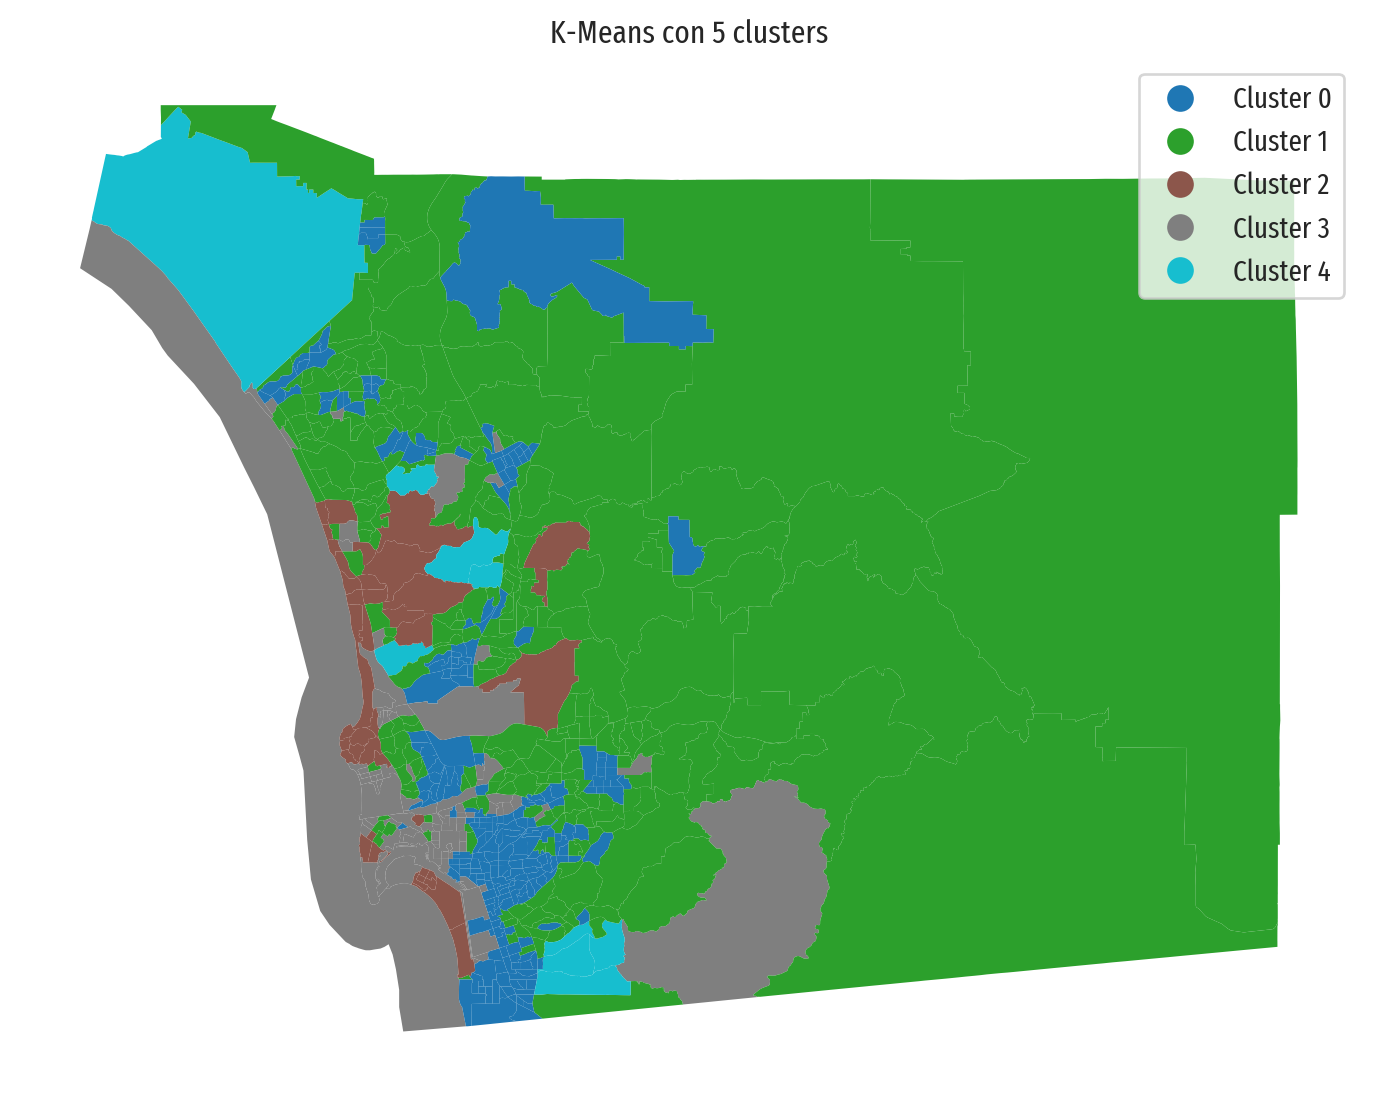

In [9]:
fig, ax = plt.subplots(figsize=(9, 9))
db.plot(column="k5", categorical=True, legend=True,
        cmap="tab10", linewidth=0, ax=ax)

# Renombrar etiquetas del legend
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(f"Cluster {text.get_text()}")

ax.set_axis_off()
ax.set_title("K-Means con 5 clusters")
plt.savefig("img/clase07/k_means_regionalizacion.png", dpi=150, bbox_inches="tight")
plt.show()

**Observación importante:** los clusters están geográficamente **fragmentados**. Un mismo grupo aparece en varias zonas inconexas del mapa. Esto es esperable: K-Means agrupa por *similitud de atributos*, no por geografía. Dos tracts con el mismo perfil socioeconómico van al mismo grupo aunque estén lejos.

Para entender qué define a cada cluster, miremos el perfil promedio:

In [10]:
perfil_k5 = db.groupby("k5")[cluster_variables].mean().round(2)
perfil_k5

,median_house_value,pct_white,pct_rented,pct_hh_female,pct_bachelor,median_no_rooms,income_gini,median_age,tt_work
k5,,,,,,,,,
0,356782.60,0.62,0.55,0.11,0.02,4.61,0.40,32.75,2234.87
1,535180.08,0.79,0.27,0.11,0.01,5.84,0.40,41.95,2252.32
2,1281945.12,0.87,0.27,0.11,0.00,6.14,0.49,46.41,1733.85
3,544888.74,0.74,0.60,0.07,0.01,4.15,0.45,32.59,2349.51
4,609385.66,0.58,0.38,0.10,0.01,5.80,0.39,33.50,9671.56


Comparando filas se ve qué hace distinto a cada grupo. Por ejemplo, el cluster 2 son barrios con median_house_value muy alto (~$1.3M) y pct_white cercano al 90% — el perfil de las zonas más acomodadas y homogéneas étnicamente. En cambio el cluster 0 tiene los precios más bajos y la mayor proporción de arrendatarios — barrios más populares con población más móvil.

## 5. Clustering Aglomerativo Jerárquico (AHC)

K-Means asume que todos los grupos son similares en tamaño y forma esférica. AHC no asume nada de eso. Construye una **jerarquía** de clusters de la siguiente forma:

1. Cada observación es su propio cluster.
2. En cada paso, se unen los **dos clusters más cercanos**.
3. Se repite hasta llegar a un solo cluster que contiene todo.

El resultado es un árbol (dendrograma). Para obtener $k$ grupos, *cortamos* el árbol a la altura adecuada.

La pregunta clave es: ¿cómo se mide la distancia entre dos *clusters* (no entre dos puntos)? Existen varias opciones — `linkage` —. Usamos **Ward**, que en cada paso une los dos clusters cuya unión produce el **menor incremento de la varianza interna**:

$$ \Delta(A, B) = \frac{|A||B|}{|A|+|B|}\, \| \bar x_A - \bar x_B \|^2 $$

donde $|A|$ es el tamaño del cluster $A$ y $\bar x_A$ su centroide. Ward tiende a producir clusters compactos, similares en tamaño.

In [11]:
ahc = AgglomerativeClustering(linkage="ward", n_clusters=5)
ahc.fit(db_scaled)
db["ahc5"] = ahc.labels_

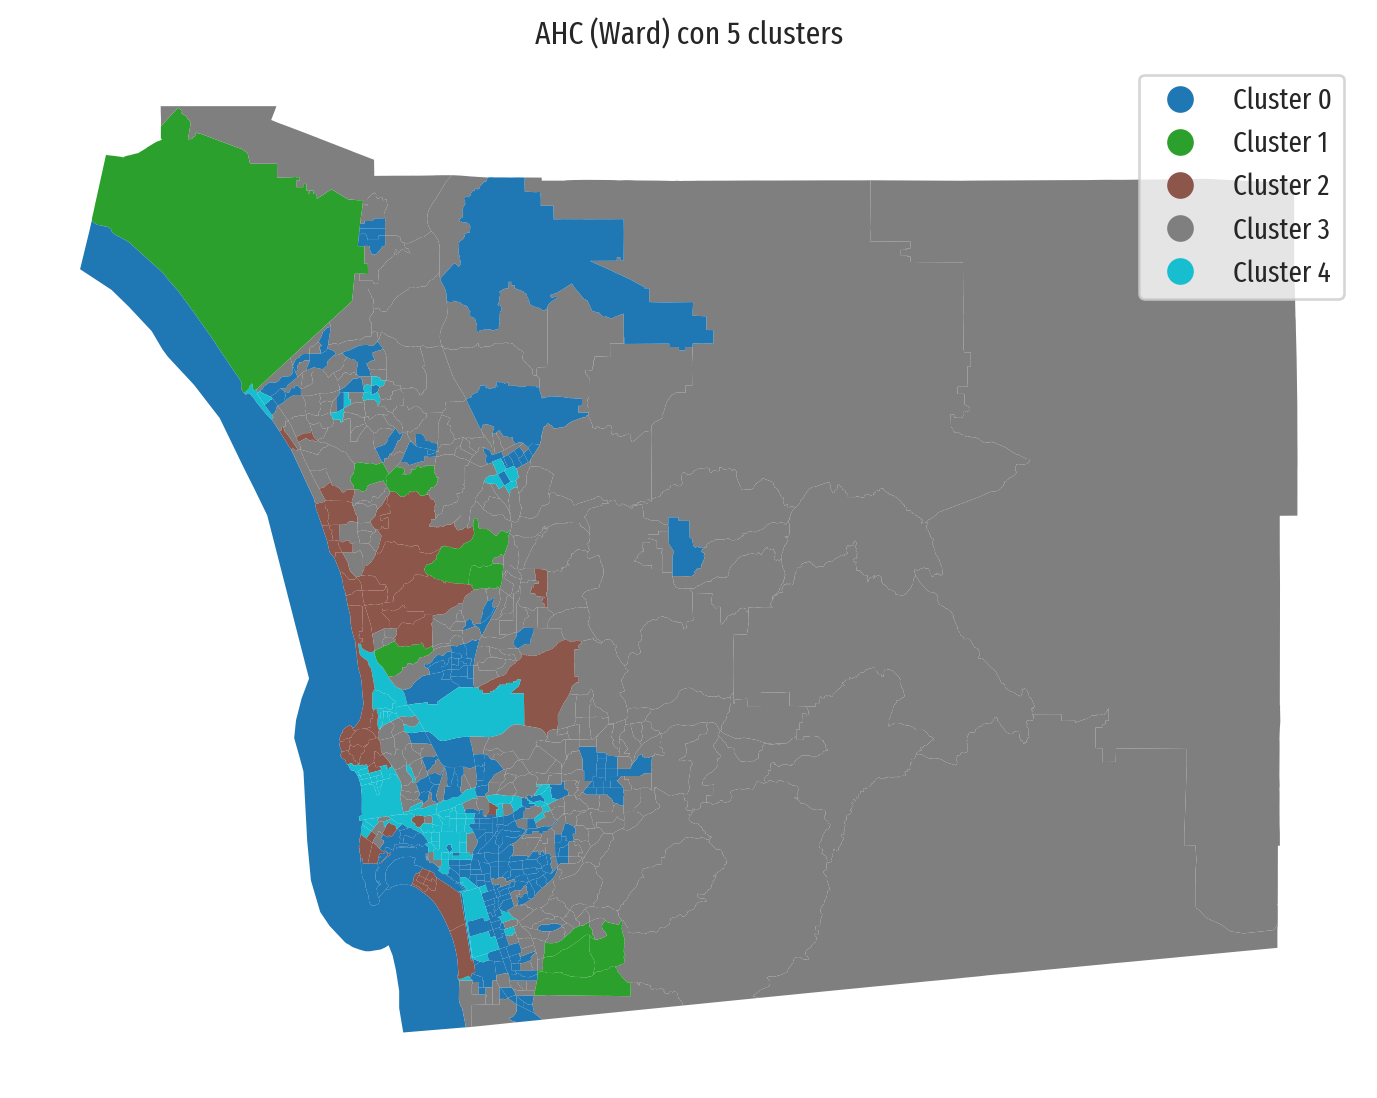

In [12]:
fig, ax = plt.subplots(figsize=(9, 9))
db.plot(column="ahc5", categorical=True, legend=True,
        cmap="tab10", linewidth=0, ax=ax)

legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(f"Cluster {text.get_text()}")

ax.set_axis_off()
ax.set_title("AHC (Ward) con 5 clusters")
plt.savefig("img/clase07/ahc5_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

El mapa también muestra fragmentación, aunque el patrón es algo más limpio que en K-Means. Sigue sin haber restricción geográfica: AHC todavía agrupa por similitud, no por contigüidad.

## 6. ¿Por qué necesitamos regionalización?

Si el objetivo final es **definir regiones** (distritos, áreas de planificación, zonas de servicios), un cluster fragmentado en 8 trozos por toda la ciudad no sirve. Necesitamos imponer que los miembros de un mismo grupo estén **conectados** en el mapa.

Esto es **regionalización**: clustering + restricción espacial.

Una forma natural de hacerlo es usar AHC con un parámetro adicional — `connectivity` — que recibe una **matriz de pesos espaciales**. El algoritmo sólo va a permitir fusionar clusters que sean *vecinos* según esa matriz.

### 6.1 Regionalización con contigüidad Queen

Usamos la matriz Queen (clase 02): dos tracts son vecinos si comparten cualquier punto en su frontera. Es la noción más estándar de "vecindad" para polígonos.

In [13]:
w_queen = Queen.from_dataframe(db, use_index=False)

ahc_queen = AgglomerativeClustering(
    linkage="ward",
    n_clusters=5,
    connectivity=w_queen.sparse,
)
ahc_queen.fit(db_scaled)
db["reg_queen"] = ahc_queen.labels_

In [14]:
db.head()

,GEOID,median_age,total_pop,total_pop_white,tt_work,hh_total,hh_female,total_bachelor,median_hh_income,income_gini,total_housing_units,total_rented,median_no_rooms,median_house_value,NAME,state,county,tract,area_sqm,pct_rented,pct_hh_female,pct_bachelor,pct_white,sub_30,geometry,k5,ahc5,reg_queen
0,06073018300,37.1,2590.0,2375.0,1299.0,2590.0,137.0,0.0,62500.0,0.5355,2530.0,946.0,3.9,732900.000000,"Census Tract 183, San Diego County, California",06,073,018300,2.876449,0.373913,0.052896,0.000000,0.916988,False,"POLYGON ((-13069450.120 3922380.770, -13069175...",3,4,3
1,06073018601,41.2,5147.0,4069.0,1970.0,5147.0,562.0,24.0,88165.0,0.4265,1633.0,335.0,6.5,473800.000000,"Census Tract 186.01, San Diego County, California",06,073,018601,4.548797,0.205144,0.109190,0.004663,0.790558,False,"POLYGON ((-13067719.770 3922939.420, -13067631...",1,3,3
2,06073017601,54.4,5595.0,4925.0,1702.0,5595.0,442.0,34.0,110804.0,0.4985,2308.0,644.0,6.2,930600.000000,"Census Tract 176.01, San Diego County, California",06,073,017601,8.726275,0.279029,0.078999,0.006077,0.880250,False,"POLYGON ((-13058166.110 3907247.690, -13058140...",2,2,4
3,06073019301,42.3,7026.0,5625.0,3390.0,7026.0,638.0,46.0,100539.0,0.4003,2351.0,462.0,6.6,478500.000000,"Census Tract 193.01, San Diego County, California",06,073,019301,3.519743,0.196512,0.090806,0.006547,0.800598,False,"POLYGON ((-13056896.290 3925255.610, -13056868...",1,3,3
4,06073018700,21.8,40402.0,30455.0,24143.0,40402.0,2456.0,23.0,41709.0,0.3196,7523.0,7146.0,5.4,515570.896382,"Census Tract 187, San Diego County, California",06,073,018700,559.150793,0.949887,0.060789,0.000569,0.753799,False,"POLYGON ((-13090788.510 3946435.430, -13090736...",4,1,2


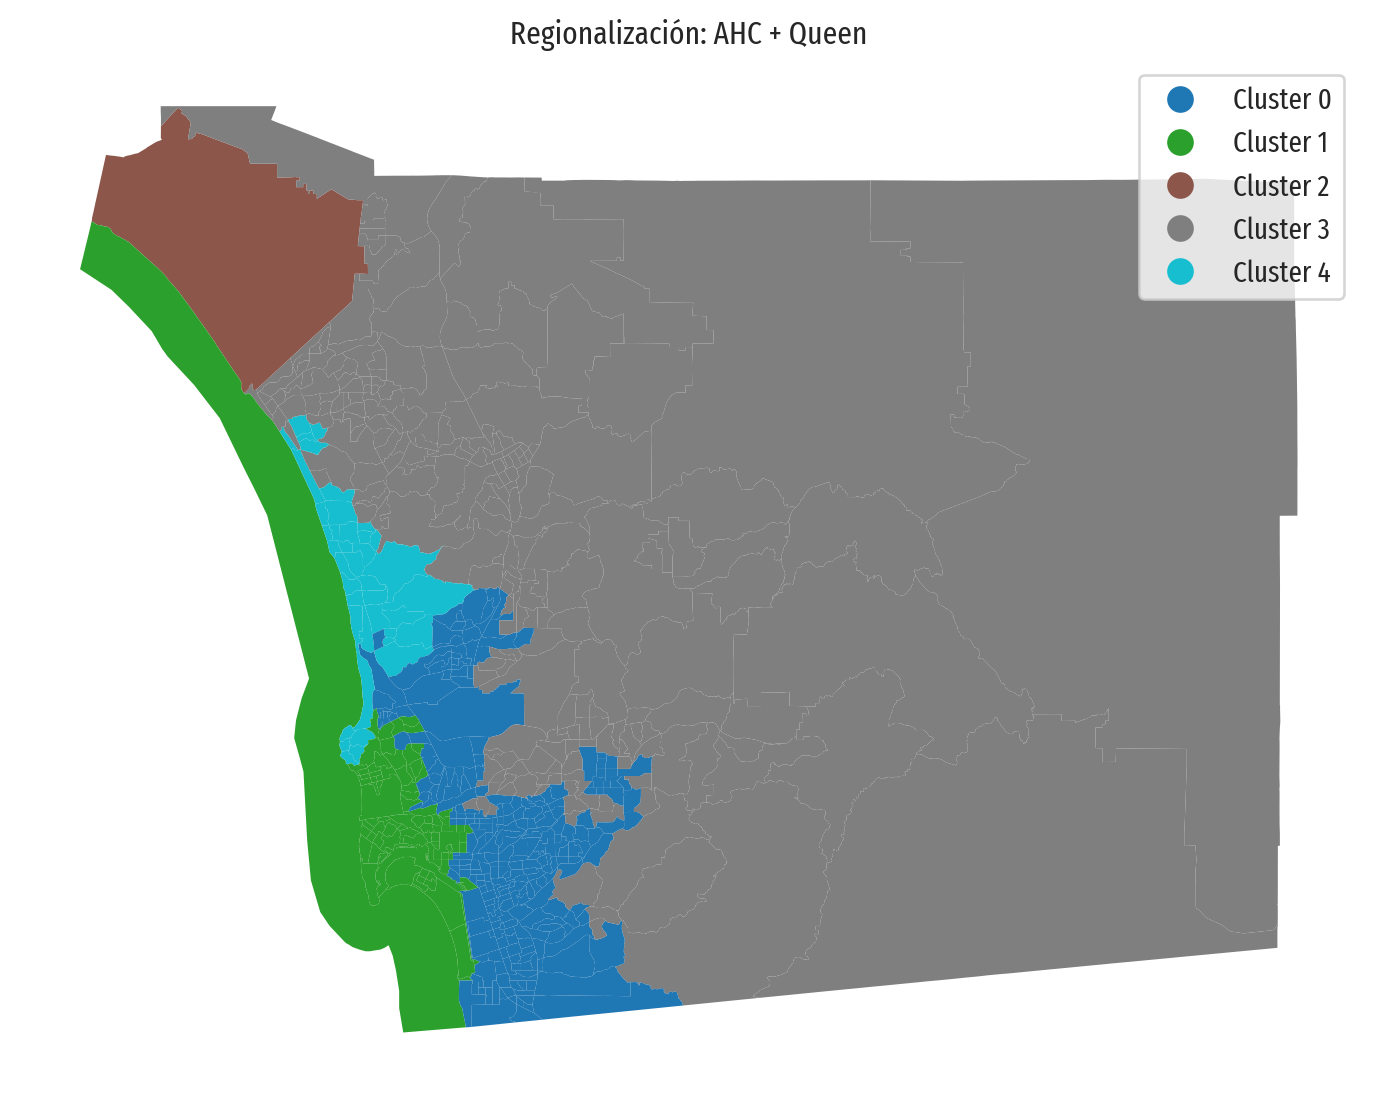

In [15]:
fig, ax = plt.subplots(figsize=(9, 9))
db.plot(column="reg_queen", categorical=True, legend=True,
        cmap="tab10", linewidth=0, ax=ax)

legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(f"Cluster {text.get_text()}")

ax.set_axis_off()
ax.set_title("Regionalización: AHC + Queen")
plt.savefig("img/clase07/reg_queen_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

Ahora cada grupo es una **región contigua**. La diferencia visual con el K-Means es enorme: los colores ya no se reparten por todo el mapa, sino que ocupan zonas conexas.

### 6.2 Regionalización con K-Nearest Neighbors

Queen depende de las fronteras compartidas. Pero hay casos donde queremos que cada unidad tenga *exactamente* el mismo número de vecinos (por ejemplo, cuando hay polígonos pequeños y grandes mezclados). Para eso está KNN: cada tract se conecta a sus $k$ centroides más cercanos.

Probemos con $k=4$:

In [16]:
w_knn = KNN.from_dataframe(db, k=4)

ahc_knn = AgglomerativeClustering(
    linkage="ward",
    n_clusters=5,
    connectivity=w_knn.sparse,
)
ahc_knn.fit(db_scaled)
db["reg_knn"] = ahc_knn.labels_

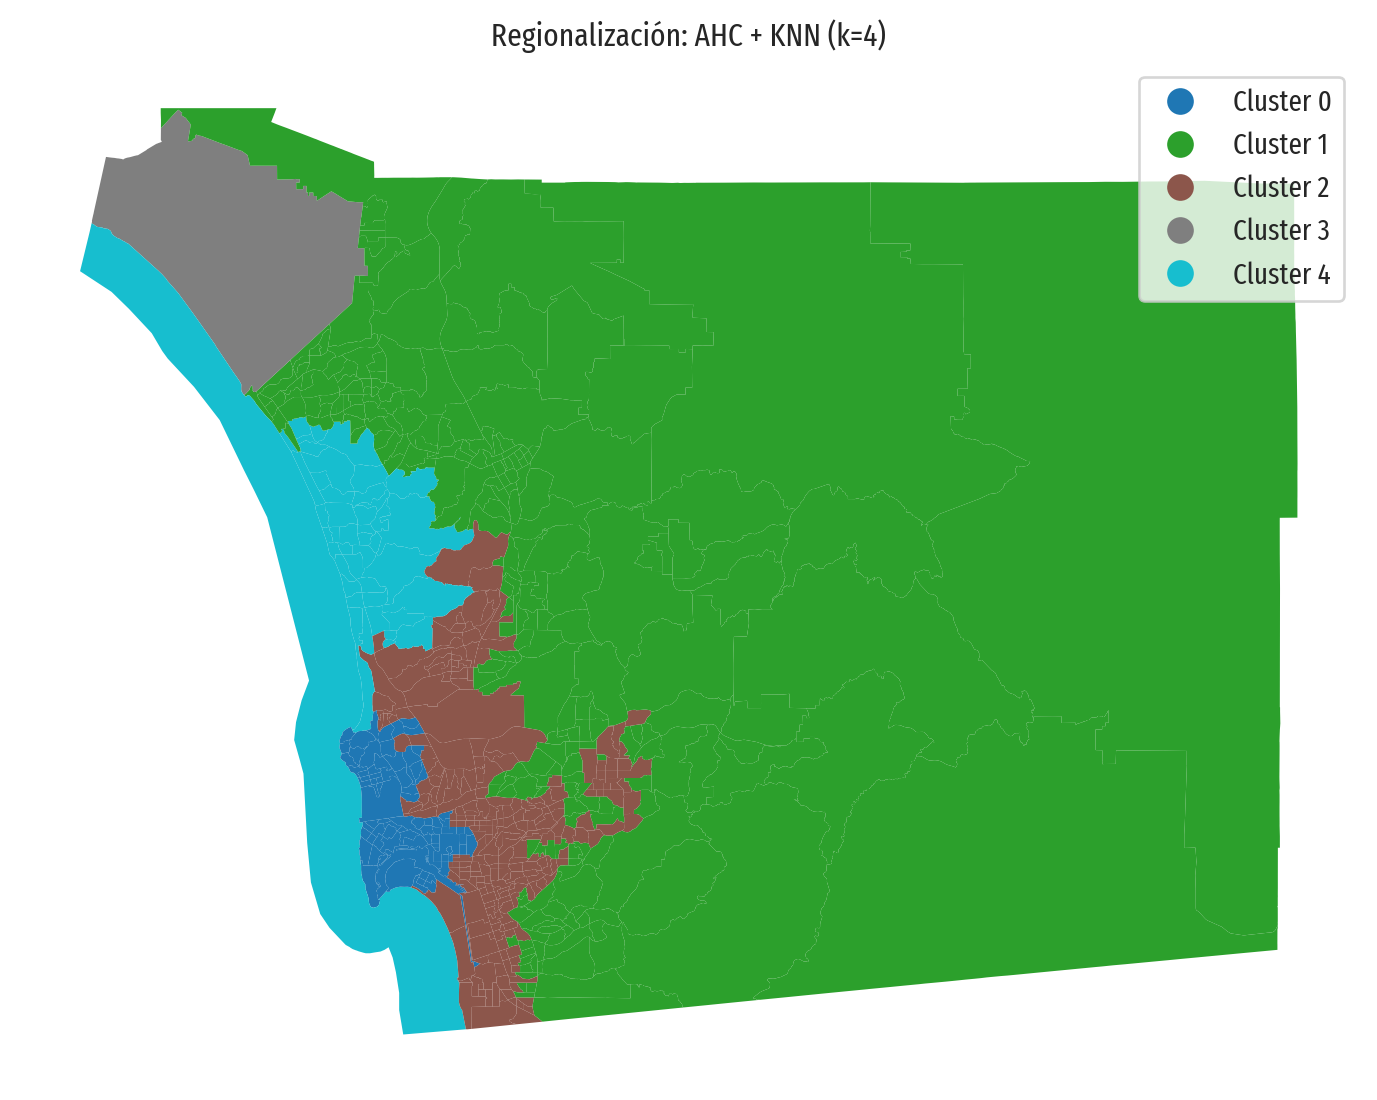

In [17]:
fig, ax = plt.subplots(figsize=(9, 9))
db.plot(column="reg_knn", categorical=True, legend=True,
        cmap="tab10", linewidth=0, ax=ax)

legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(f"Cluster {text.get_text()}")

ax.set_axis_off()
ax.set_title("Regionalización: AHC + KNN (k=4)")
plt.savefig("img/clase07/reg_knn_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

**Comparación importante:** las regiones de Queen y KNN no son idénticas. La elección de la matriz de pesos influye en el resultado. No hay una respuesta única "correcta": depende del problema.

## 7. Comparando los cuatro resultados

Pongamos los cuatro mapas lado a lado para apreciar la diferencia:

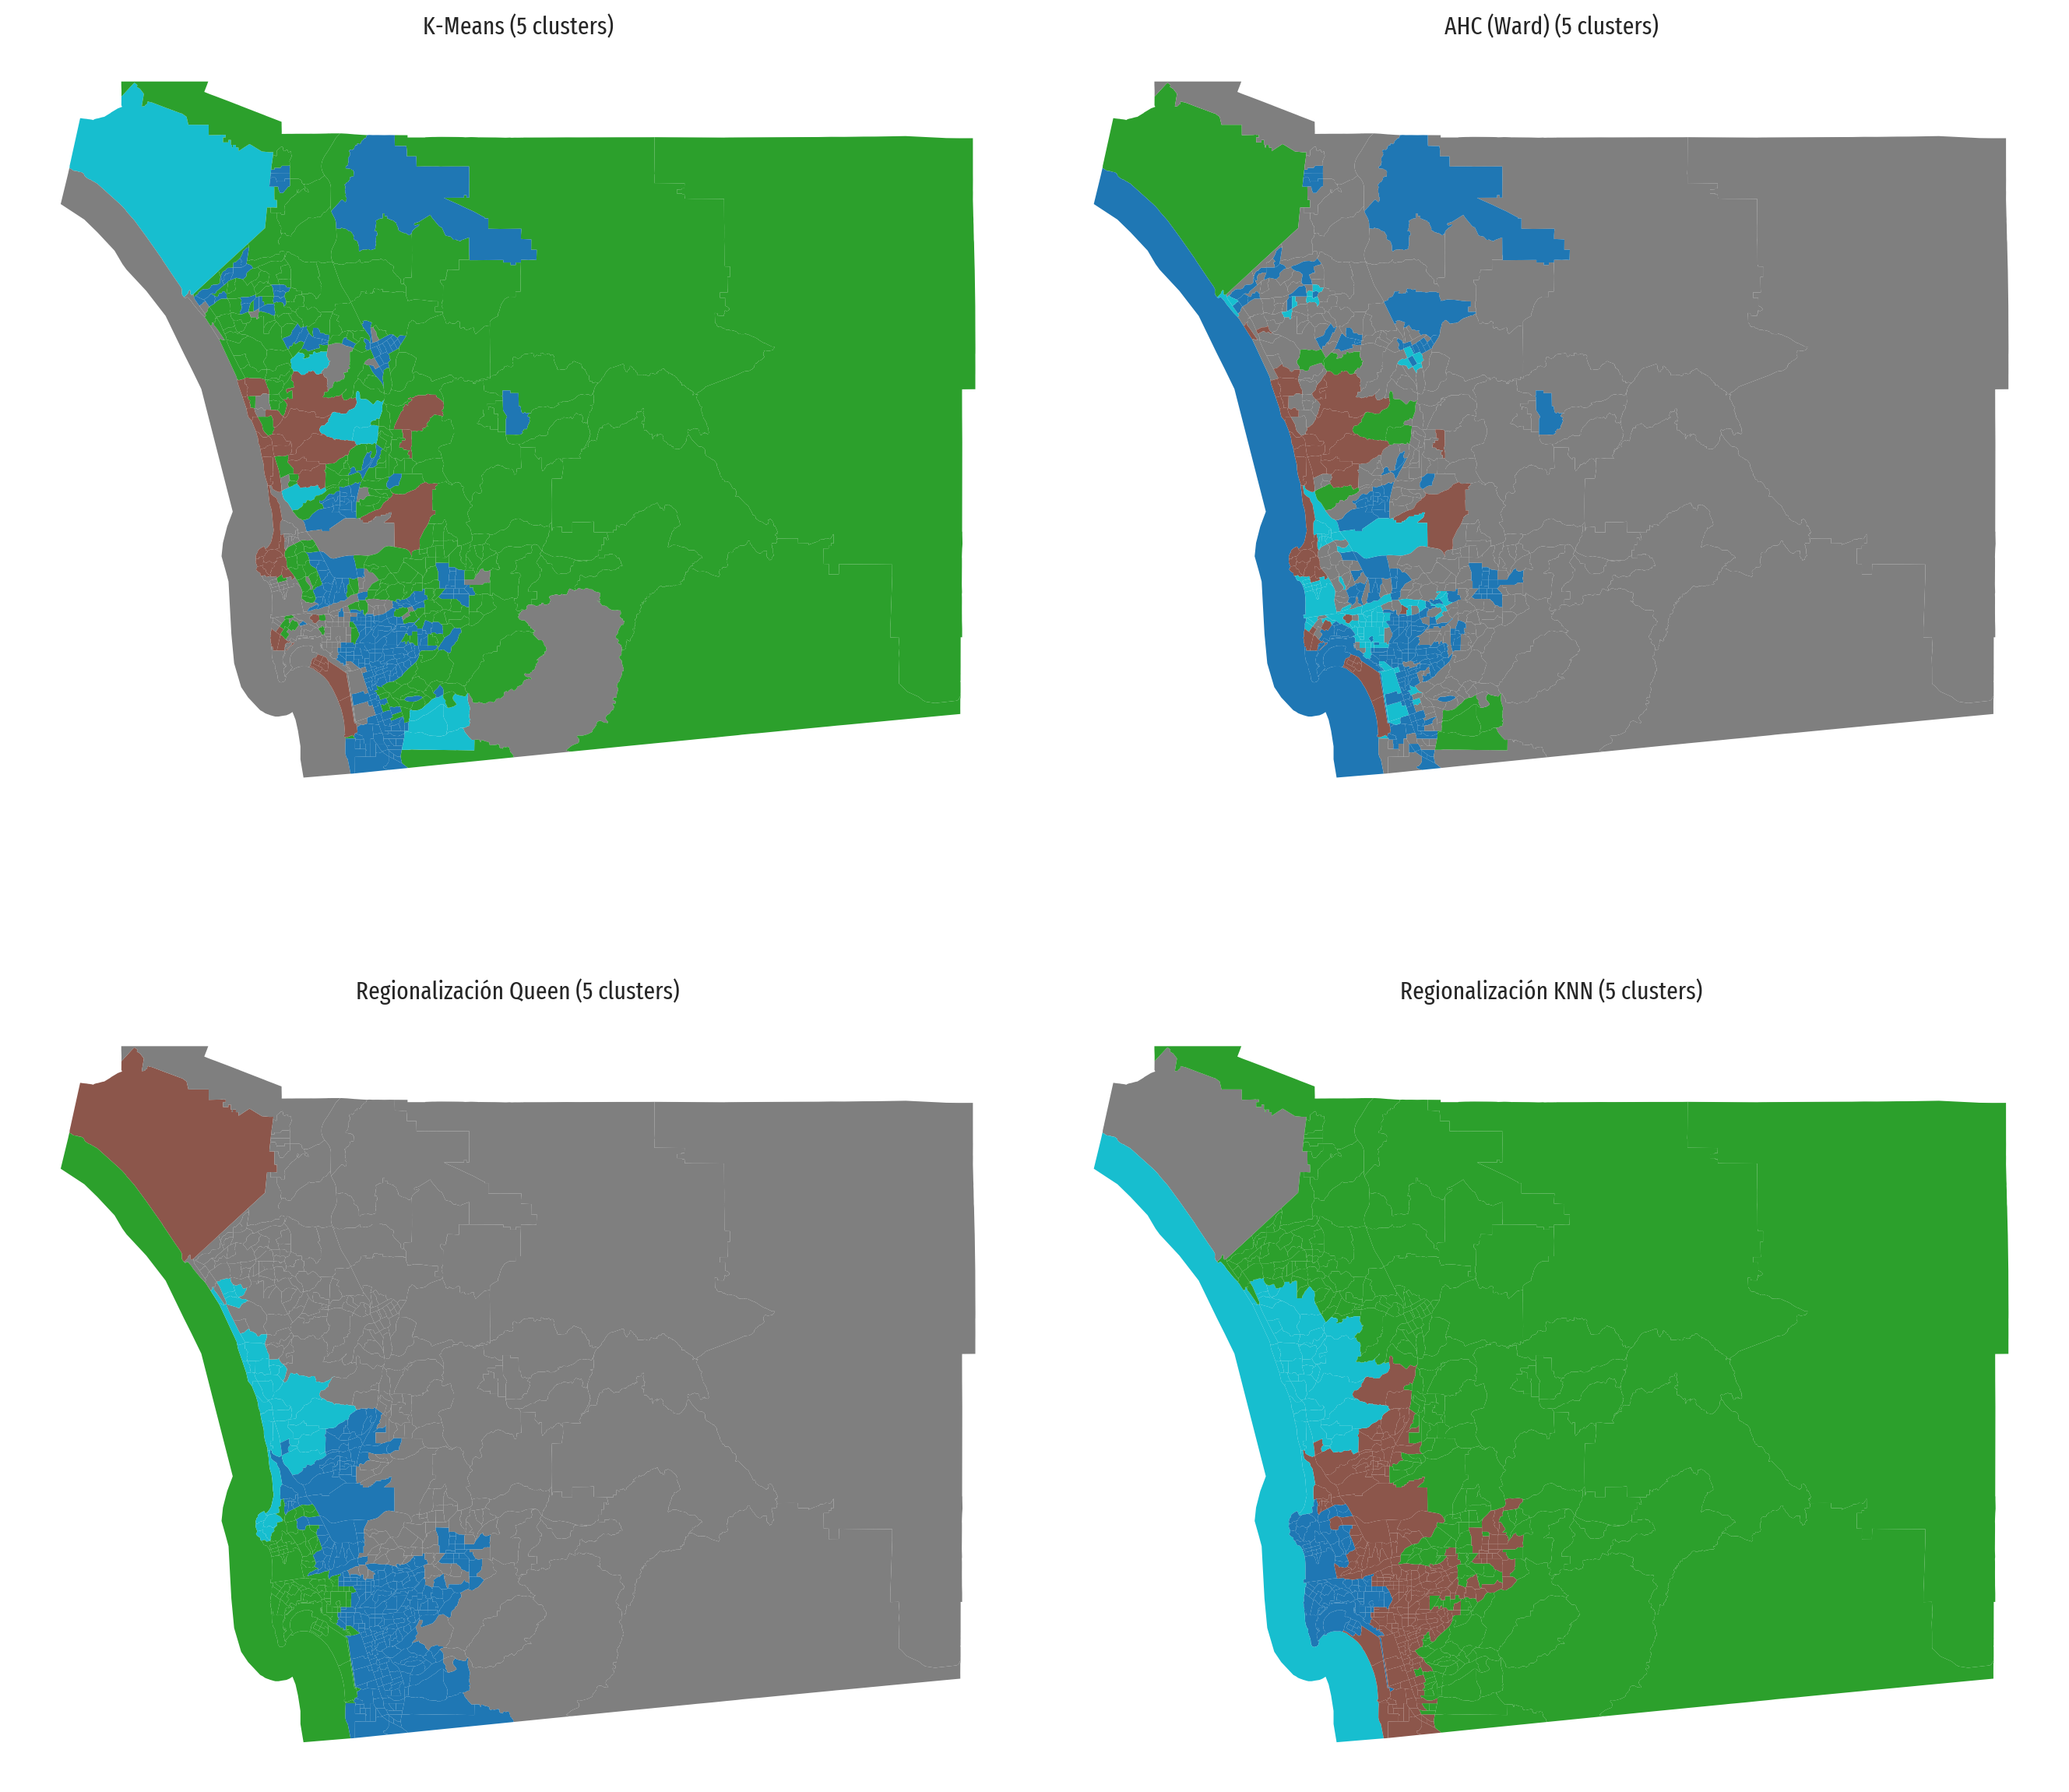

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(14, 14))
for ax, col, titulo in zip(
    axs.flatten(),
    ["k5", "ahc5", "reg_queen", "reg_knn"],
    ["K-Means", "AHC (Ward)", "Regionalización Queen", "Regionalización KNN"],
):
    n = db[col].nunique()
    db.plot(column=col, categorical=True, cmap="tab10", linewidth=0, ax=ax)
    ax.set_axis_off()
    ax.set_title(f"{titulo} ({n} clusters)")
plt.tight_layout()
plt.savefig("img/clase07/comparacion_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. ¿Qué solución es mejor? Dos métricas complementarias

Hay un *trade-off* claro: la regionalización paga un costo en términos de homogeneidad de atributos (los grupos son menos parecidos internamente) a cambio de coherencia geográfica. Cuantifiquemos las dos cosas.

### 8.1 Coherencia de atributos

Medimos cuán homogéneo es cada grupo en sus variables usando la **suma de cuadrados intra-cluster**:

$$ \text{WCSS} = \sum_{c} \sum_{i \in C_c} \| x_i - \bar x_c \|^2 $$

Cuanto **menor** sea este número, más parecidas son las observaciones dentro de cada grupo.

In [19]:
def wcss(etiquetas, X):
    total = 0.0
    for c in np.unique(etiquetas):
        Xc = X[etiquetas == c]
        total += ((Xc - Xc.mean(axis=0)) ** 2).sum()
    return total

resultados = pd.DataFrame(index=["K-Means", "AHC", "Reg. Queen", "Reg. KNN"])
resultados["WCSS"] = [
    wcss(db["k5"].values,        db_scaled),
    wcss(db["ahc5"].values,      db_scaled),
    wcss(db["reg_queen"].values, db_scaled),
    wcss(db["reg_knn"].values,   db_scaled),
]
resultados

,WCSS
K-Means,2515.894197
AHC,2679.904726
Reg. Queen,3122.042265
Reg. KNN,3242.986568


Como esperábamos, **K-Means tiene la WCSS más baja**: justamente fue lo que el algoritmo optimizó. Las regionalizaciones tienen WCSS más alta — sus grupos son menos puros en atributos, porque tuvieron que respetar la geografía.

### 8.2 Coherencia geográfica

La forma más directa de medirla es contar **cuántos componentes conexos** tiene cada cluster en el mapa. Una regionalización ideal debería tener exactamente un componente por grupo (cada grupo es una sola región). Par esto usamos el metodo `connected_components`, que recibe la submatriz de vecindad de un cluster y retorna cuántos grupos desconectados hay dentro de él. El parámetro `directed=False` indica que la vecindad es simétrica (si A es vecino de B, B es vecino de A).

In [20]:
def n_componentes(etiquetas, w):
    """Para cada cluster, cuenta cuántas piezas inconexas tiene en el mapa."""
    from scipy.sparse.csgraph import connected_components
    total = 0
    for c in np.unique(etiquetas):
        idx = np.where(etiquetas == c)[0]
        sub = w.sparse[idx][:, idx]
        n_comp, _ = connected_components(sub, directed=False)
        total += n_comp
    return total

resultados["# componentes"] = [
    n_componentes(db["k5"].values,        w_queen),
    n_componentes(db["ahc5"].values,      w_queen),
    n_componentes(db["reg_queen"].values, w_queen),
    n_componentes(db["reg_knn"].values,   w_queen),
]
resultados

,WCSS,# componentes
K-Means,2515.894197,60
AHC,2679.904726,62
Reg. Queen,3122.042265,5
Reg. KNN,3242.986568,6


Las regionalizaciones tienen **muchos menos componentes** que los métodos no espaciales (idealmente 5: uno por grupo). Las soluciones con K-Means y AHC, en cambio, generan decenas de fragmentos.

**Resumen del trade-off:**

| Método | WCSS (atributos) | # componentes (geografía) |
|---|:--:|:--:|
| K-Means | mejor | peor |
| AHC | medio | peor |
| Regionalización (Queen / KNN) | peor | mejor |

No hay un método absolutamente mejor. La elección depende del **uso**:

- ¿Necesitamos una **clasificación** descriptiva (tipologías, perfiles)? → clustering.
- ¿Necesitamos delimitar **regiones operativas** (distritos, áreas de gestión)? → regionalización.

## 9. Conclusión

Lo importante de esta clase no es tanto el algoritmo concreto como la distinción conceptual:

- **Clustering** agrupa por *similitud* en los atributos.
- **Regionalización** agrupa por *similitud + contigüidad espacial*.

Pasamos de uno a otro con un cambio mínimo de código (agregar `connectivity=w.sparse` a AHC), pero el resultado cambia radicalmente.

Algunas ideas para llevarse:

1. **Estandarizar siempre** antes de calcular distancias entre observaciones.
2. **Verificar autocorrelación espacial** en las variables: si no la hay, regionalizar tiene poco sentido.
3. **Hay un trade-off** entre homogeneidad de atributos y contigüidad espacial. Los métodos espaciales son siempre "peores" en homogeneidad pura y "mejores" en coherencia geográfica.
4. La **matriz de pesos** (Queen, Rook, KNN, distancias) cambia el resultado. Hay que justificar la elección.

## Para profundizar

- Rey, S., Arribas-Bel, D. & Wolf, L. J. (2020). *Geographic Data Science with Python*, Capítulo 10.
- Duque, J.C., Ramos, R. & Suriñach, J. (2007). Supervised regionalization methods: a survey. *International Regional Science Review*, 30(3).
- Algoritmos avanzados (no cubiertos): **SKATER**, **AZP**, **max-p**. Disponibles en `pysal`/`spopt` para casos donde Ward+contigüidad no basta.